# 12 â€” Final Test Evaluation
Retrain each winner on train+val, evaluate ONCE on the untouched test set. No tuning after this point.

In [1]:

import sys, os
from pathlib import Path
root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
import json
import joblib
import pandas as pd
from src.config import SPLITS_DIR, RESULTS_DIR, MODELS_DIR, FEATURES, TARGETS_REG, TARGET_CLF
from src.tune import make_est
from src.preprocessing import build_preprocessor
from src.evaluate import reg_metrics, clf_metrics, confusion

trainval = pd.concat([pd.read_csv(SPLITS_DIR / "train.csv"), pd.read_csv(SPLITS_DIR / "val.csv")], ignore_index=True)
test = pd.read_csv(SPLITS_DIR / "test.csv")
winners = json.load(open(RESULTS_DIR / "winners.json"))

def fit_eval(kind, winner_name, target):
    base = winner_name.replace("_tuned", "")
    y_tr = trainval[target]
    spw = 1.0
    if kind == "clf":
        y_tr = y_tr.astype(int)
        spw = float((y_tr == 0).sum()) / max((y_tr == 1).sum(), 1)
    params = {}
    if winner_name.endswith("_tuned"):
        tuned_file = RESULTS_DIR / "optuna" / f"{kind}_{base}_{target}_best.json"
        if tuned_file.exists():
            params = json.load(open(tuned_file))["best_params"]
    est = make_est(kind, base, params, spw=spw)
    prep = build_preprocessor()
    Xt = prep.fit_transform(trainval[FEATURES])
    est.fit(Xt, y_tr)
    joblib.dump({"prep": prep, "model": est}, MODELS_DIR / f"final_{target}.joblib")
    Xte = prep.transform(test[FEATURES])
    if kind == "reg":
        return reg_metrics(test[target], est.predict(Xte))
    proba = est.predict_proba(Xte)[:, 1] if hasattr(est, "predict_proba") else est.decision_function(Xte)
    m = clf_metrics(test[target].astype(int), proba)
    m["confusion_matrix"] = confusion(test[target], proba)
    return m

final = {}
for w in winners["regression"]:
    final[w["target"]] = fit_eval("reg", w["model"], w["target"])
    print(w["target"], w["model"], "->", {k: round(v, 4) for k, v in final[w["target"]].items()}, flush=True)

final[TARGET_CLF] = fit_eval("clf", winners["classification"]["model"], TARGET_CLF)
print(TARGET_CLF, winners["classification"]["model"], "->",
      {k: round(v, 4) for k, v in final[TARGET_CLF].items() if k != "confusion_matrix"},
      "| CM:", final[TARGET_CLF]["confusion_matrix"])

flat = {f"{t}.{k}": v for t, m in final.items() for k, v in m.items()}
json.dump(flat, open(RESULTS_DIR / "final_test_results.json", "w"), indent=2)
rows = [{"target": t, **{k: (round(v, 4) if isinstance(v, float) else str(v)) for k, v in m.items()}} for t, m in final.items()]
pd.DataFrame(rows).to_csv(RESULTS_DIR / "final_test_results.csv", index=False)
pd.DataFrame(rows)


next_cycle_length random_forest_tuned -> {'mae': 1.1982, 'rmse': 1.7608, 'r2': 0.7984}


next_period_length random_forest_tuned -> {'mae': 0.5856, 'rmse': 0.7355, 'r2': 0.6715}


next_is_irregular random_forest_tuned -> {'pr_auc': 0.8736, 'f1': 0.7508, 'roc_auc': 0.974} | CM: [[2599, 128], [32, 241]]


,target,mae,rmse,r2,pr_auc,f1,roc_auc,confusion_matrix
0,next_cycle_length,1.1982,1.7608,0.7984,NaN,NaN,NaN,NaN
1,next_period_length,0.5856,0.7355,0.6715,NaN,NaN,NaN,NaN
2,next_is_irregular,NaN,NaN,NaN,0.8736,0.7508,0.974,"[[2599, 128], [32, 241]]"


## Added diagnostics — training curves & full evaluation panels\nLearning/loss curves fit on train with val evaluation (test untouched); all diagnostic plots use out-of-fold predictions on train+val.

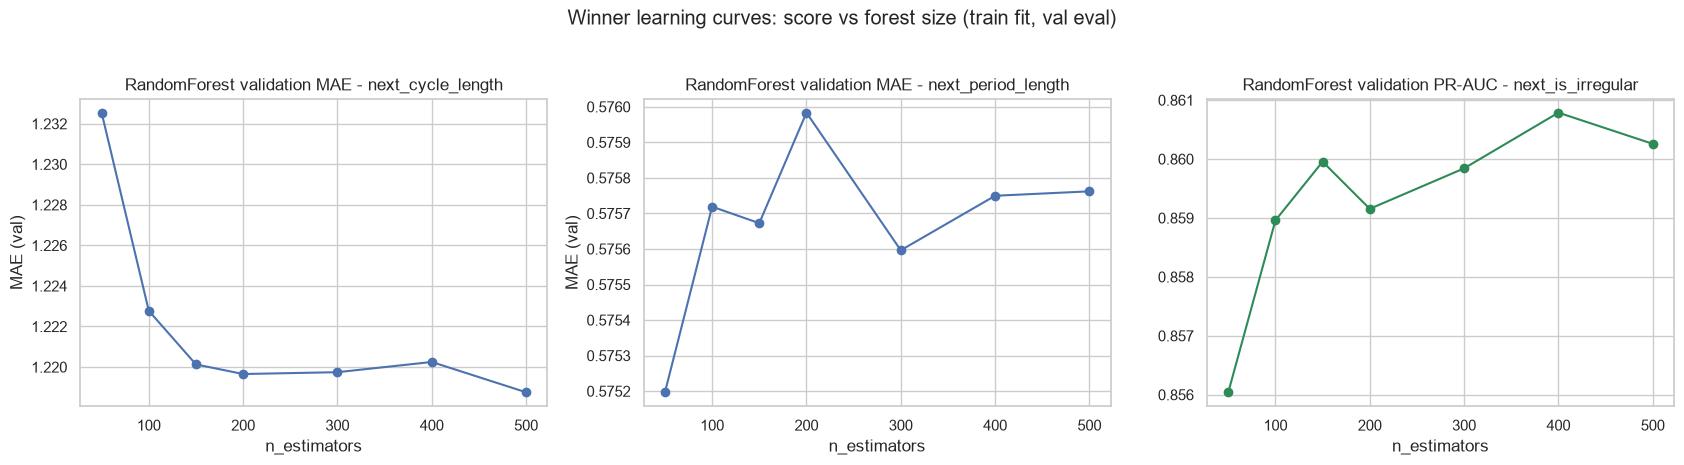

[0]	validation_0-mae:2.70086	validation_1-mae:2.74590


[1]	validation_0-mae:2.65863	validation_1-mae:2.70421


[2]	validation_0-mae:2.61800	validation_1-mae:2.66416


[3]	validation_0-mae:2.57815	validation_1-mae:2.62483


[4]	validation_0-mae:2.53951	validation_1-mae:2.58645


...

[135]	validation_0-aucpr:0.89261	validation_1-aucpr:0.85657


[136]	validation_0-aucpr:0.89272	validation_1-aucpr:0.85656

[137]	validation_0-aucpr:0.89298	validation_1-aucpr:0.85636


[138]	validation_0-aucpr:0.89301	validation_1-aucpr:0.85627

E:\NAVYA_MODEL\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


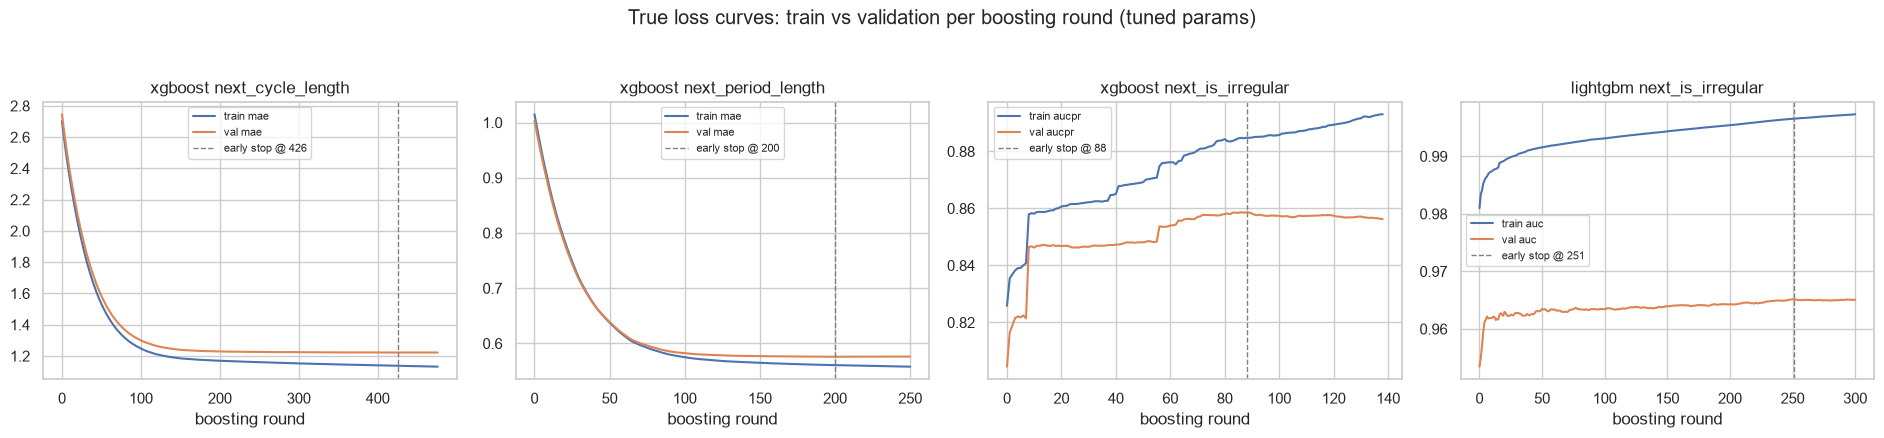

In [2]:
ns_grid = [50, 100, 150, 200, 300, 400, 500]
curve_rows = []
for target in TARGETS_REG:
    wn = winner_info("reg", target).replace("_tuned", "")
    if wn != "random_forest":
        continue
    q = {k: v for k, v in tuned_params("reg", wn, target).items() if k != "n_estimators"}
    ytr, yva = train[target], val[target]
    scores = []
    for n in ns_grid:
        m = RandomForestRegressor(n_estimators=n, random_state=SEED, n_jobs=-1, **q)
        m.fit(Xtr, ytr)
        scores.append(mean_absolute_error(yva, m.predict(Xva)))
    curve_rows.append((target, scores))
wn = winner_info("clf", TARGET_CLF).replace("_tuned", "")
clf_scores = None
if wn == "random_forest":
    q = {k: v for k, v in tuned_params("clf", wn, TARGET_CLF).items() if k != "n_estimators"}
    ytr, yva = train[TARGET_CLF].astype(int), val[TARGET_CLF].astype(int)
    clf_scores = []
    for n in ns_grid:
        m = RandomForestClassifier(n_estimators=n, random_state=SEED, n_jobs=-1,
                                   class_weight="balanced", **q)
        m.fit(Xtr, ytr)
        clf_scores.append(average_precision_score(yva, m.predict_proba(Xva)[:, 1]))
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (target, scores) in zip(axes[:2], curve_rows):
    ax.plot(ns_grid, scores, marker="o"); ax.set_title(f"RandomForest validation MAE - {target}")
    ax.set_xlabel("n_estimators"); ax.set_ylabel("MAE (val)")
if clf_scores is not None:
    axes[2].plot(ns_grid, clf_scores, marker="o", color="seagreen")
    axes[2].set_title(f"RandomForest validation PR-AUC - {TARGET_CLF}")
    axes[2].set_xlabel("n_estimators")
plt.suptitle("Winner learning curves: score vs forest size (train fit, val eval)", y=1.03)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "final_rf_val_curves.png", dpi=150, bbox_inches="tight"); plt.show()

def boost_curve(kind, algo, target, ax):
    q = tuned_params(kind, algo, target)
    ytr, yva = train[target], val[target]
    spw = 1.0
    if kind == "clf":
        ytr, yva = ytr.astype(int), yva.astype(int)
        spw = float((ytr == 0).sum()) / max((ytr == 1).sum(), 1)
    est = make_est(kind, algo, q, spw=spw, es=True)
    fit_kw = {"eval_set": [(Xtr, ytr), (Xva, yva)]}
    if algo == "lightgbm":
        fit_kw["callbacks"] = [lgb_es(50, verbose=False)]
        fit_kw["eval_metric"] = "auc" if kind == "clf" else "l1"
    est.set_params(n_jobs=-1)
    est.fit(Xtr, ytr, **fit_kw)
    er = getattr(est, "evals_result", None)
    res = er() if callable(er) else est.evals_result_
    items = list(res.items())
    metric = list(items[0][1].keys())[0]
    tr_s = items[0][1][metric]; va_s = items[1][1][metric]
    best_it = getattr(est, "best_iteration", getattr(est, "best_iteration_", None))
    ax.plot(tr_s, label=f"train {metric}"); ax.plot(va_s, label=f"val {metric}")
    if best_it is not None:
        ax.axvline(best_it, color="gray", ls="--", lw=1, label=f"early stop @ {best_it}")
    ax.set_title(f"{algo} {target}"); ax.set_xlabel("boosting round"); ax.legend(fontsize=8)

combos = [("reg", "xgboost", TARGETS_REG[0]), ("reg", "xgboost", TARGETS_REG[1]),
          ("clf", "xgboost", TARGET_CLF), ("clf", "lightgbm", TARGET_CLF)]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
for ax, (kind, algo, target) in zip(axes, combos):
    boost_curve(kind, algo, target, ax)
plt.suptitle("True loss curves: train vs validation per boosting round (tuned params)", y=1.04)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "final_boosting_loss_curves.png", dpi=150, bbox_inches="tight"); plt.show()


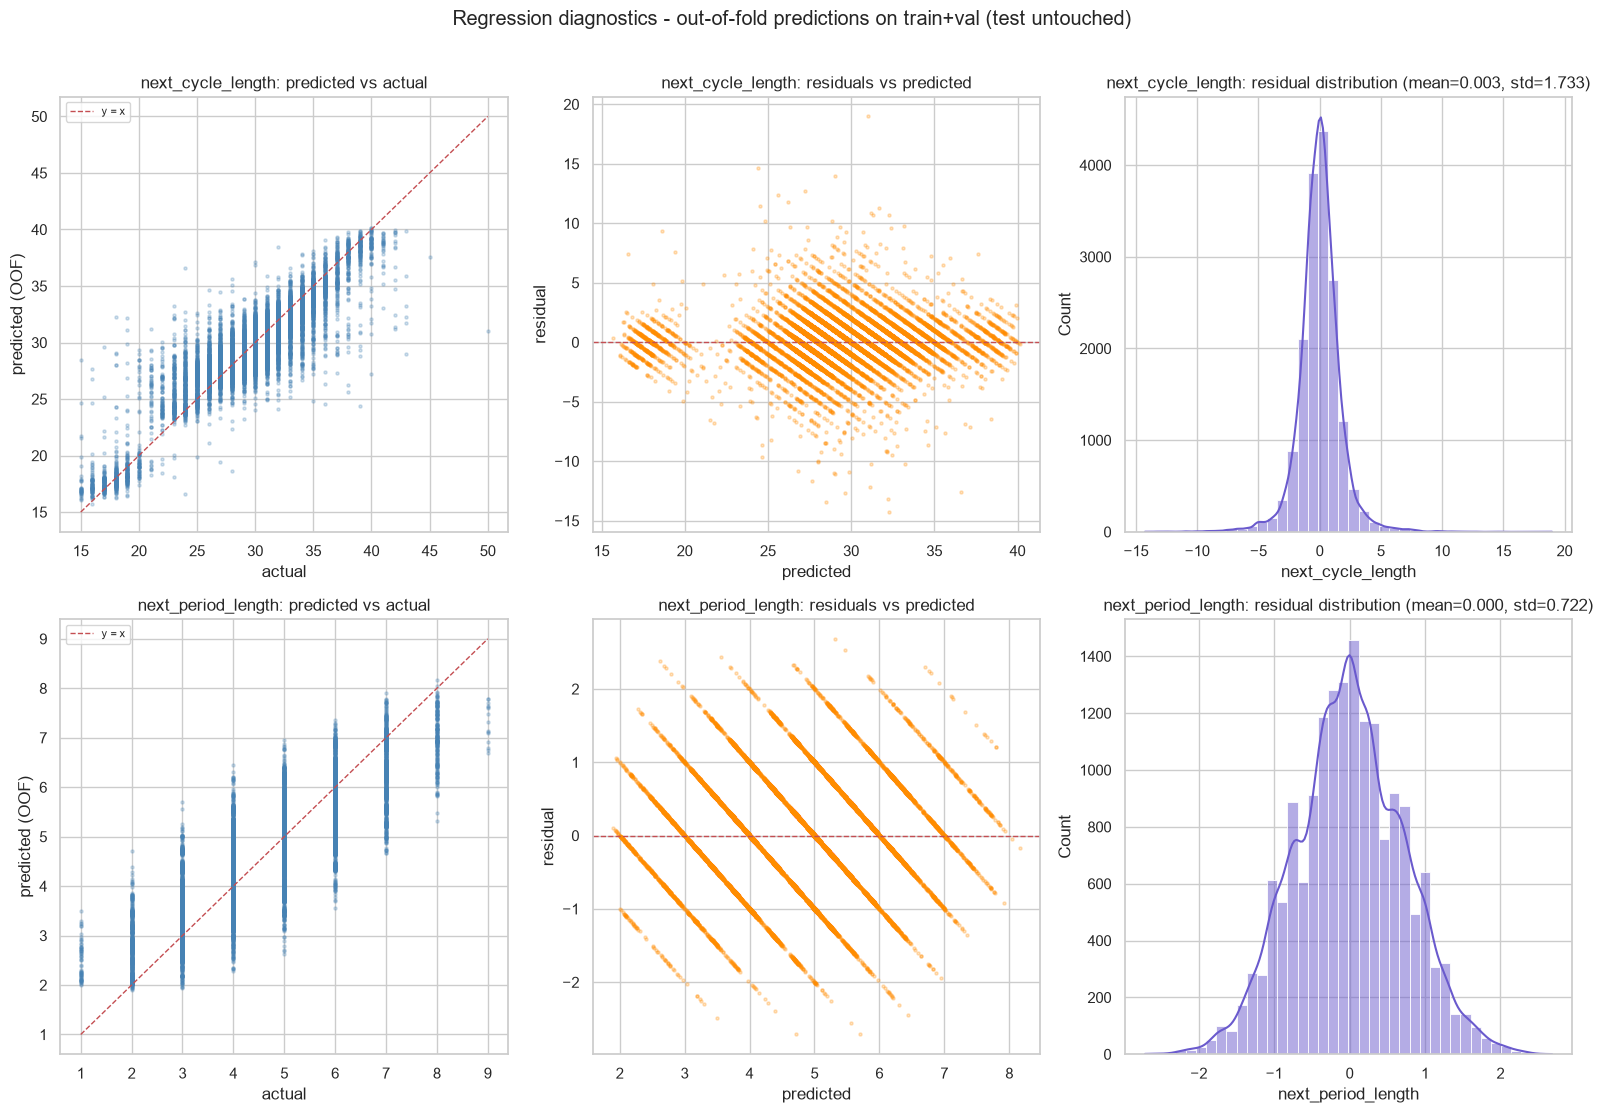

In [3]:
from sklearn.model_selection import KFold, cross_val_predict

trainval = pd.concat([train, val], ignore_index=True)
fig, axes = plt.subplots(len(TARGETS_REG), 3, figsize=(16, 11))
for r, target in enumerate(TARGETS_REG):
    wn = winner_info("reg", target)
    base = wn.replace("_tuned", "")
    q = tuned_params("reg", base, target) if wn.endswith("_tuned") else {}
    pipe = make_pipeline(make_est("reg", base, q))
    pred = cross_val_predict(pipe, trainval[FEATURES], trainval[target],
                             cv=KFold(5, shuffle=True, random_state=SEED))
    actual = trainval[target]; resid = actual - pred
    ax = axes[r, 0]
    ax.scatter(actual, pred, s=5, alpha=0.25, color="steelblue")
    lims = [actual.min(), actual.max()]
    ax.plot(lims, lims, "r--", lw=1, label="y = x")
    ax.set_xlabel("actual"); ax.set_ylabel("predicted (OOF)")
    ax.set_title(f"{target}: predicted vs actual"); ax.legend(fontsize=8)
    ax = axes[r, 1]
    ax.scatter(pred, resid, s=5, alpha=0.25, color="darkorange")
    ax.axhline(0, color="r", ls="--", lw=1)
    ax.set_xlabel("predicted"); ax.set_ylabel("residual")
    ax.set_title(f"{target}: residuals vs predicted")
    ax = axes[r, 2]
    sns.histplot(resid, bins=40, kde=True, ax=ax, color="slateblue")
    ax.set_title(f"{target}: residual distribution (mean={resid.mean():.3f}, std={resid.std():.3f})")
plt.suptitle("Regression diagnostics - out-of-fold predictions on train+val (test untouched)", y=1.01)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "final_reg_diagnostics.png", dpi=150, bbox_inches="tight"); plt.show()


OOF PR-AUC=0.8738 | default 0.5 -> P=0.668 R=0.854 F1=0.750 | best-F1 threshold 0.74 -> F1=0.795 (R=0.757, P=0.837)


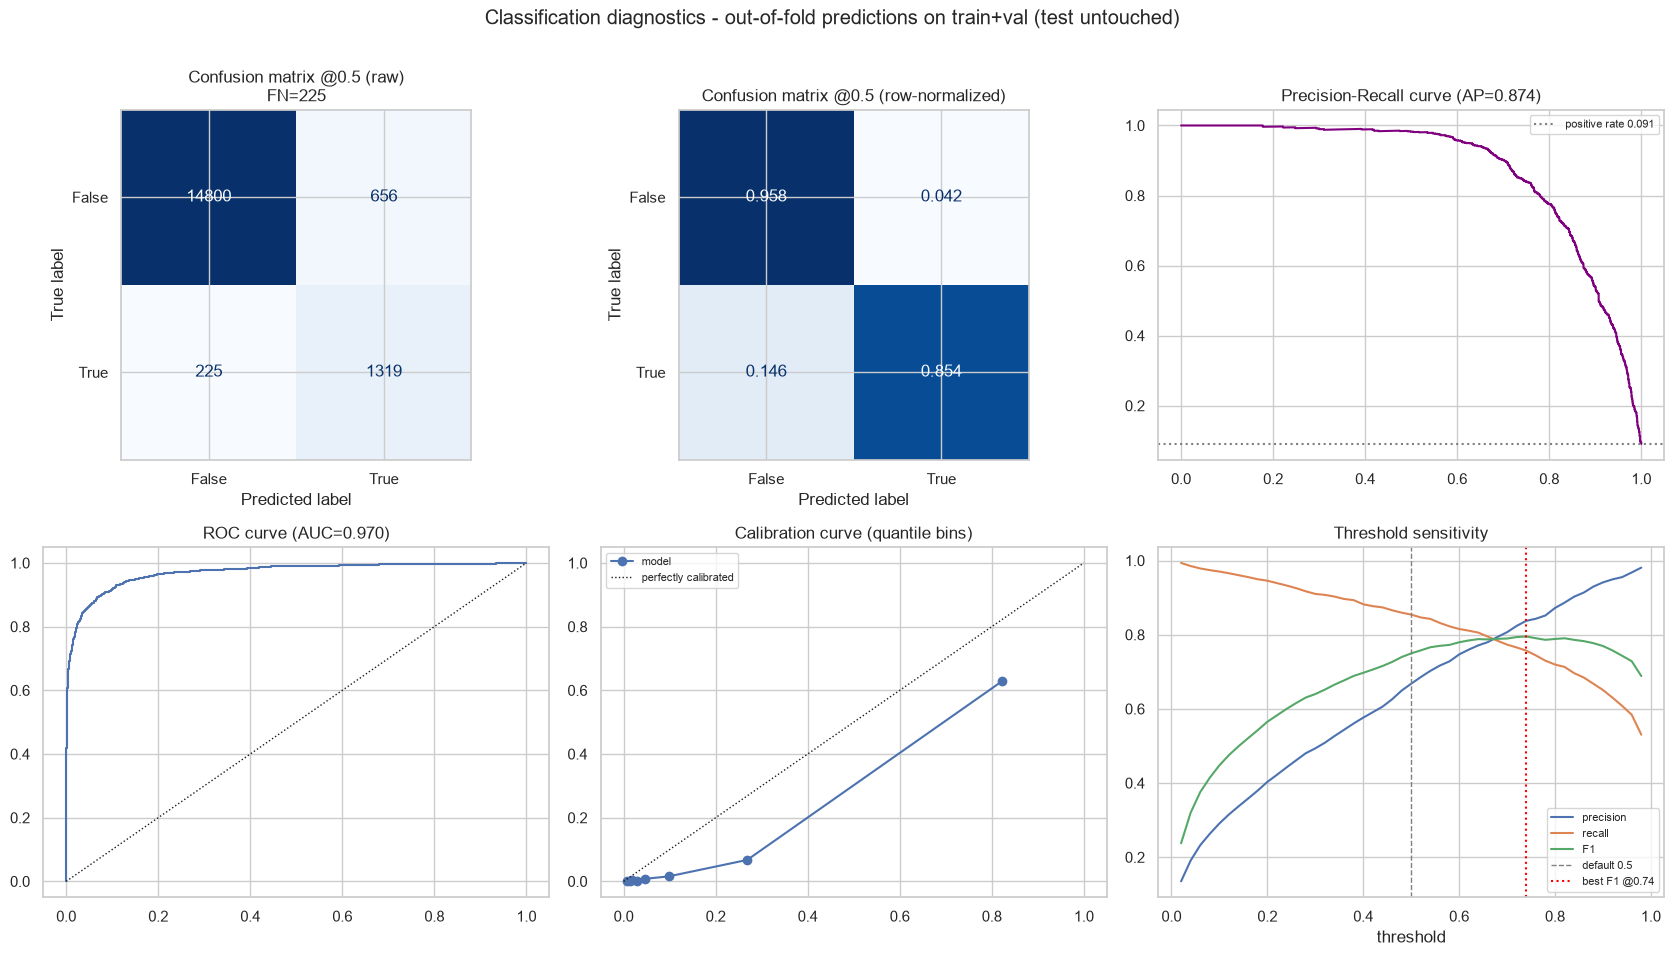

In [4]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                             precision_recall_curve, precision_score,
                             recall_score, roc_curve)

ycl = trainval[TARGET_CLF].astype(int)
wn = winner_info("clf", TARGET_CLF)
base = wn.replace("_tuned", "")
spw = float((ycl == 0).sum()) / max((ycl == 1).sum(), 1)
q = tuned_params("clf", base, TARGET_CLF) if wn.endswith("_tuned") else {}
est = make_est("clf", base, q, spw=spw)
pipe = make_pipeline(est)
method = "predict_proba" if hasattr(est, "predict_proba") else "decision_function"
raw_oof = cross_val_predict(pipe, trainval[FEATURES], ycl,
                            cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                            method=method)
proba = raw_oof[:, 1] if raw_oof.ndim == 2 else raw_oof
pred05 = (proba >= 0.5).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(17, 9.5))
ConfusionMatrixDisplay(confusion_matrix(ycl, pred05), display_labels=[False, True]).plot(ax=axes[0, 0], cmap="Blues", colorbar=False)
axes[0, 0].set_title(f"Confusion matrix @0.5 (raw)\nFN={confusion_matrix(ycl, pred05)[1,0]}")
cmn = confusion_matrix(ycl, pred05, normalize="true")
ConfusionMatrixDisplay(cmn, display_labels=[False, True]).plot(ax=axes[0, 1], cmap="Blues", colorbar=False, values_format=".3f")
axes[0, 1].set_title("Confusion matrix @0.5 (row-normalized)")
prec, rec, _ = precision_recall_curve(ycl, proba)
ap = average_precision_score(ycl, proba)
axes[0, 2].plot(rec, prec, color="purple")
base_rate = ycl.mean()
axes[0, 2].axhline(base_rate, color="gray", ls=":", label=f"positive rate {base_rate:.3f}")
axes[0, 2].set_title(f"Precision-Recall curve (AP={ap:.3f})"); axes[0, 2].legend(fontsize=8)
fpr, tpr, _ = roc_curve(ycl, proba)
auc = roc_auc_score(ycl, proba)
axes[1, 0].plot(fpr, tpr); axes[1, 0].plot([0, 1], [0, 1], "k:", lw=1)
axes[1, 0].set_title(f"ROC curve (AUC={auc:.3f})")
pt, pp = calibration_curve(ycl, proba, n_bins=8, strategy="quantile")
axes[1, 1].plot(pp, pt, marker="o", label="model")
axes[1, 1].plot([0, 1], [0, 1], "k:", lw=1, label="perfectly calibrated")
axes[1, 1].set_title("Calibration curve (quantile bins)"); axes[1, 1].legend(fontsize=8)
ths = np.linspace(0.02, 0.98, 49)
ps, rs, fs = [], [], []
for t in ths:
    p = precision_score(ycl, (proba >= t).astype(int), zero_division=0)
    rr = recall_score(ycl, (proba >= t).astype(int), zero_division=0)
    ps.append(p); rs.append(rr); fs.append(2 * p * rr / max(p + rr, 1e-9))
axes[1, 2].plot(ths, ps, label="precision"); axes[1, 2].plot(ths, rs, label="recall"); axes[1, 2].plot(ths, fs, label="F1")
bi = int(np.argmax(fs))
axes[1, 2].axvline(0.5, color="gray", ls="--", lw=1, label="default 0.5")
axes[1, 2].axvline(ths[bi], color="red", ls=":", lw=1.5, label=f"best F1 @{ths[bi]:.2f}")
axes[1, 2].set_title("Threshold sensitivity"); axes[1, 2].set_xlabel("threshold"); axes[1, 2].legend(fontsize=8)
print(f"OOF PR-AUC={ap:.4f} | default 0.5 -> P={ps[list(ths).index(0.5)] if 0.5 in ths else precision_score(ycl, pred05):.3f} "
      f"R={recall_score(ycl, pred05):.3f} F1={f1_score(ycl, pred05):.3f} | "
      f"best-F1 threshold {ths[bi]:.2f} -> F1={fs[bi]:.3f} (R={rs[bi]:.3f}, P={ps[bi]:.3f})")
plt.suptitle("Classification diagnostics - out-of-fold predictions on train+val (test untouched)", y=1.005)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "final_clf_diagnostics.png", dpi=150, bbox_inches="tight"); plt.show()
